Train Accuracy: 0.8413333333333334
Test Accuracy: 0.8056

Train precision: 0.8336825563122053
Test precision: 0.8068635275339185

Train recall: 0.8515248796147673
Test recall: 0.8055776892430279

Train f1: 0.8425092641609317
Test f1: 0.80622009569378


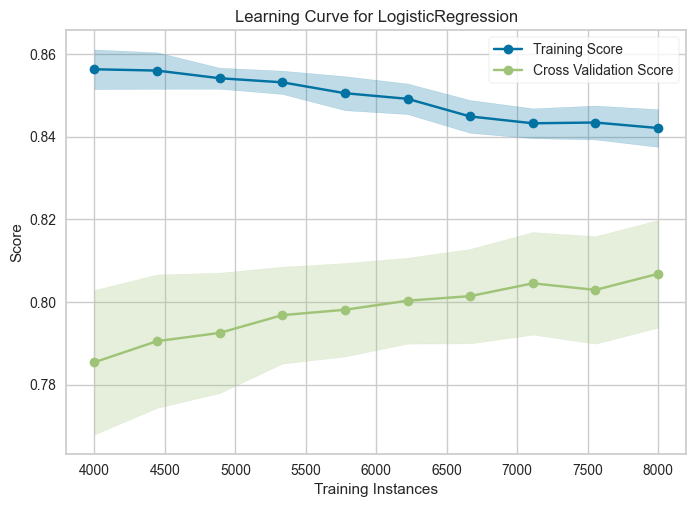

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import alpha
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from yellowbrick.model_selection import LearningCurve
from sklearn.metrics import precision_score, recall_score, f1_score

X, y = make_classification(n_samples=10000, n_features=500, n_informative=50, n_repeated=0, class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=3)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print('Train Accuracy:', logreg.score(X_train, y_train))
print('Test Accuracy:', logreg.score(X_test, y_test))
print()
print('Train precision:', precision_score(y_train, logreg.predict(X_train)))
print('Test precision:', precision_score(y_test, logreg.predict(X_test)))
print()
print('Train recall:', recall_score(y_train, logreg.predict(X_train)))
print('Test recall:', recall_score(y_test, logreg.predict(X_test)))
print()
print('Train f1:', f1_score(y_train, logreg.predict(X_train)))
print('Test f1:', f1_score(y_test, logreg.predict(X_test)))

visualizer = LearningCurve(logreg, train_sizes=np.linspace(0.5, 1.0, num=10)).fit(X, y).show()

Train Accuracy: 0.7724
Test Accuracy: 0.7712


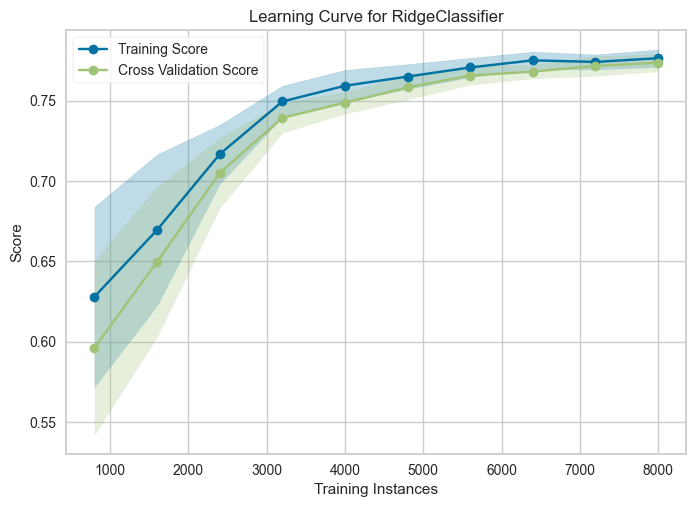

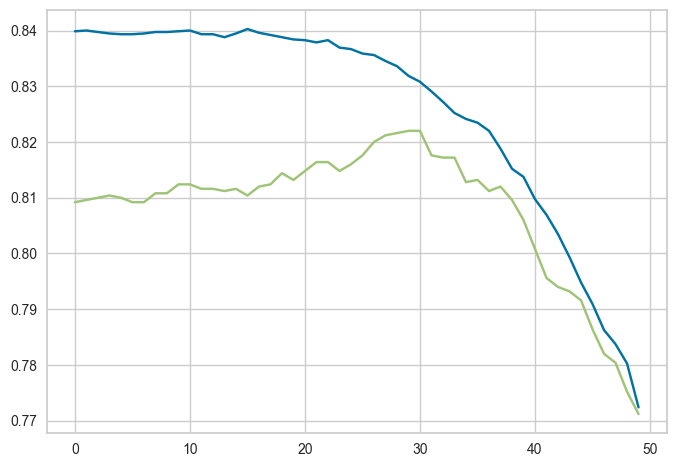

Train Accuracy: 0.8310666666666666
Test Accuracy: 0.8228


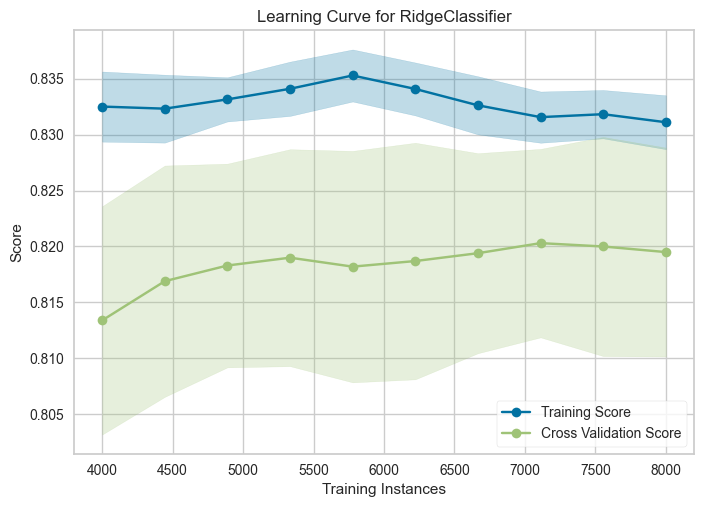

In [5]:
from sklearn.linear_model import RidgeClassifier

logreg = RidgeClassifier(alpha=1000000)
logreg.fit(X_train, y_train)

print('Train Accuracy:', logreg.score(X_train, y_train))
print('Test Accuracy:', logreg.score(X_test, y_test))

visualizer = LearningCurve(logreg, train_sizes=np.linspace(0.1, 1.0, num=10)).fit(X, y).show()

trains = []
tests = []
for i in np.logspace(2, 6, 50):
    ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label='train')
plt.plot(tests, label='test')
plt.show()

logreg = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print('Train Accuracy:', logreg.score(X_train, y_train))
print('Test Accuracy:', logreg.score(X_test, y_test))
visualizer = LearningCurve(logreg, train_sizes=np.linspace(0.5, 1.0, num=10)).fit(X, y).show()

Train Accuracy: 0.7697699488741149
Test Accuracy: 0.6354638433202133


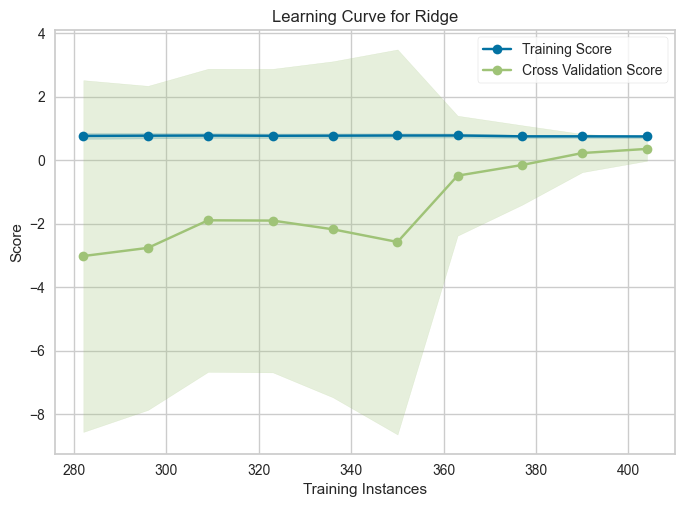

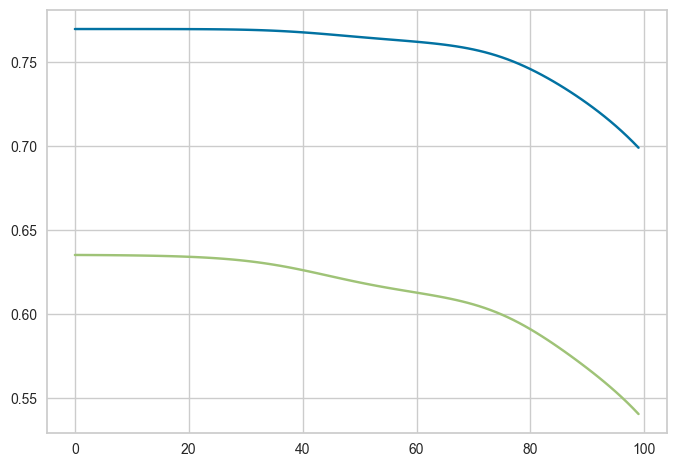

Train Accuracy: 0.7696049400382002
Test Accuracy: 0.6333846775989754


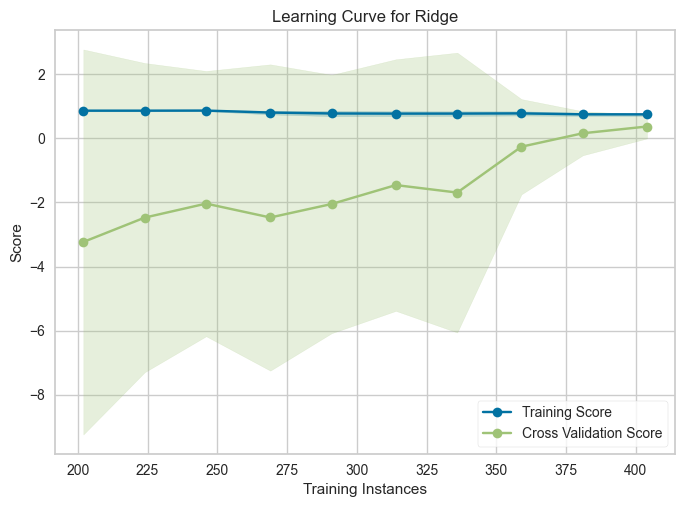

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge


dataset = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/refs/heads/master/BostonHousing.csv')
dataset.head()

X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

print('Train Accuracy:', linreg.score(X_train, y_train))
print('Test Accuracy:', linreg.score(X_test, y_test))
visualizer = LearningCurve(Ridge(alpha=0.0001), train_sizes=np.linspace(0.7, 1.0, num=10)).fit(X, y).show()

trains = []
tests = []
for i in np.logspace(-2, 3, 100):
    ridge = Ridge(alpha=i).fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label='train')
plt.plot(tests, label='test')
plt.show()

lr = Ridge(alpha=0.18).fit(X_train, y_train)

print('Train Accuracy:', lr.score(X_train, y_train))
print('Test Accuracy:', lr.score(X_test, y_test))

visualizer = LearningCurve(lr, scoring='r2', train_sizes=np.linspace(0.5, 1.0, num=10)).fit(X, y).show()

Train Accuracy: 0.9134328577979892
Test Accuracy: 0.6932540948805392
C= 10


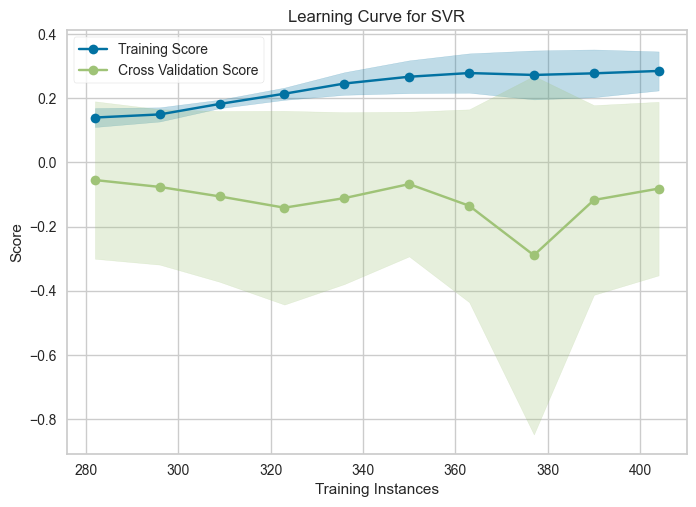

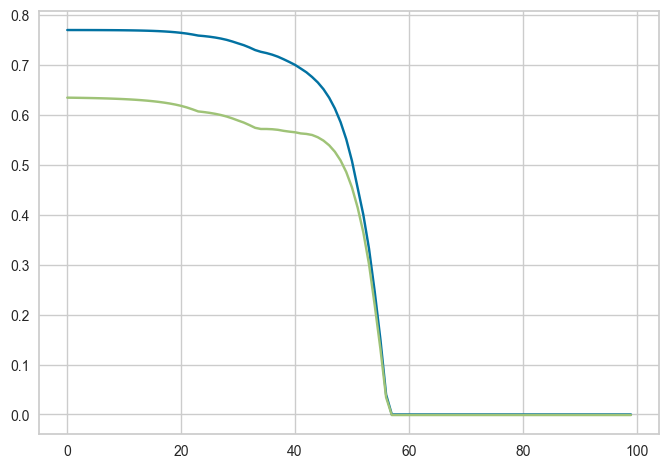

Train Accuracy: 0.9783235857999073
Test Accuracy: 0.7855896911004692
C= 100


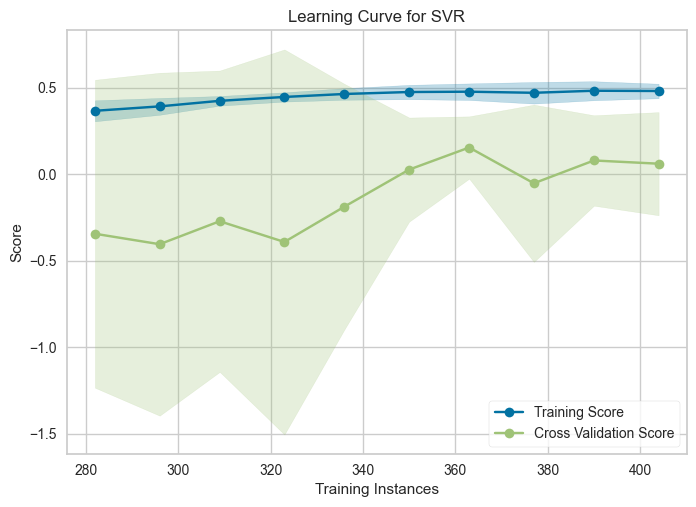

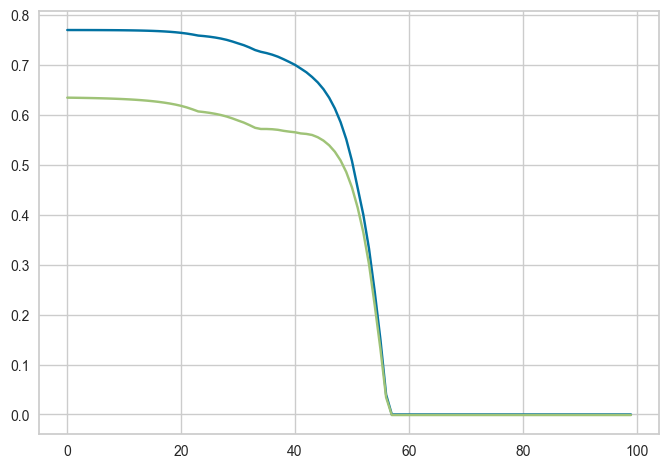

Train Accuracy: 0.9944977907204099
Test Accuracy: 0.7365039120212047
C= 1000


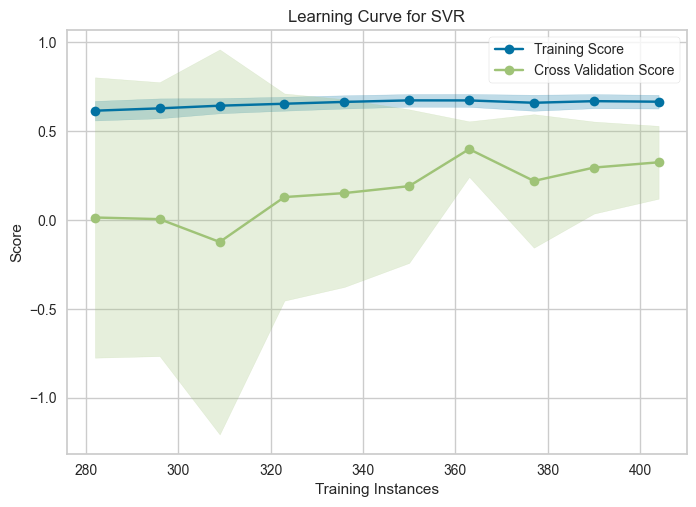

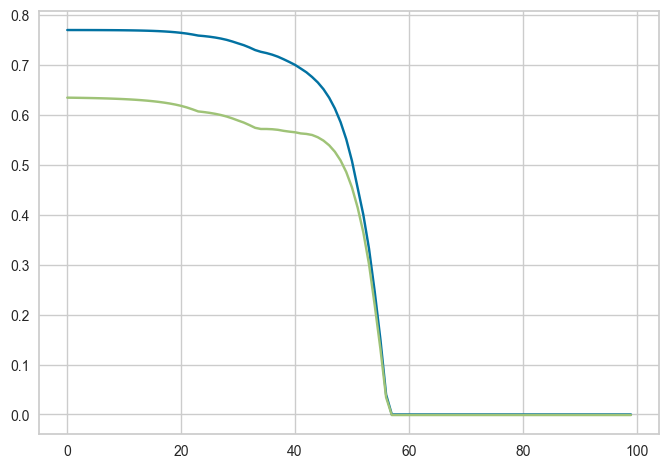

In [29]:
from sklearn.svm import SVR
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for c in [10, 100, 1000]:

    svr_model = SVR(C=c)
    svr_model.fit(X_train, y_train)

    print('Train Accuracy:', svr_model.score(X_train, y_train))
    print('Test Accuracy:', svr_model.score(X_test, y_test))
    print(f'C=', c)
    visualizer = LearningCurve(svr_model, train_sizes=np.linspace(0.7, 1.0, num=10)).fit(X, y).show()



Train Accuracy: 0.9096792469445257
Test Accuracy: 0.6248800677762865


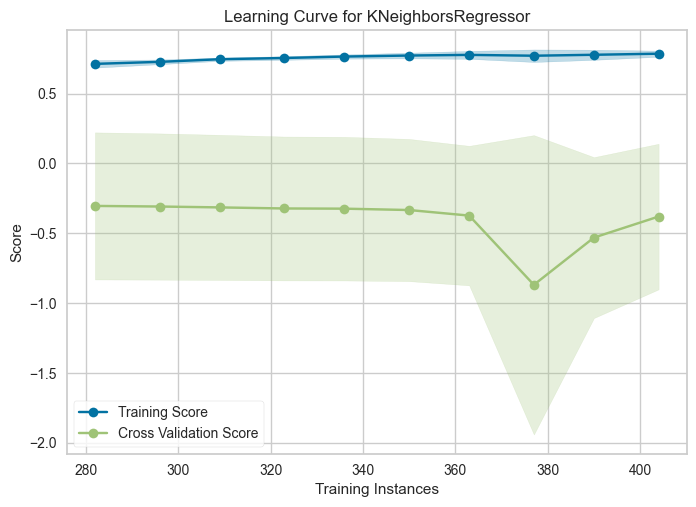

k= 3
Train Accuracy: 0.849576948978109
Test Accuracy: 0.606952770711171


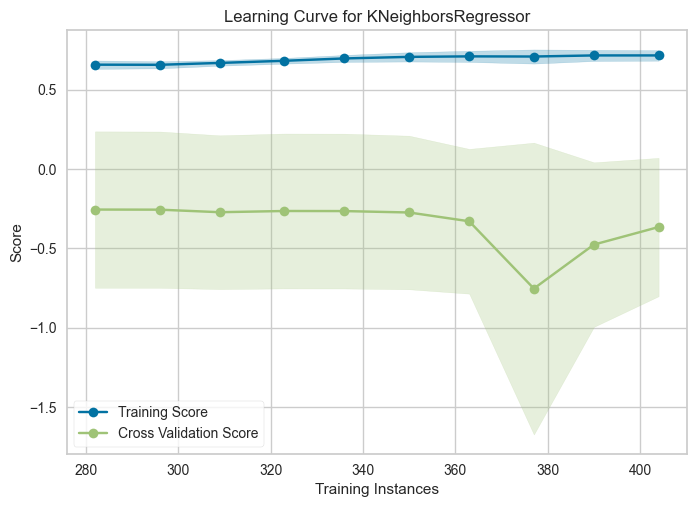

k= 5
Train Accuracy: 0.8062863564543085
Test Accuracy: 0.6003937522033265


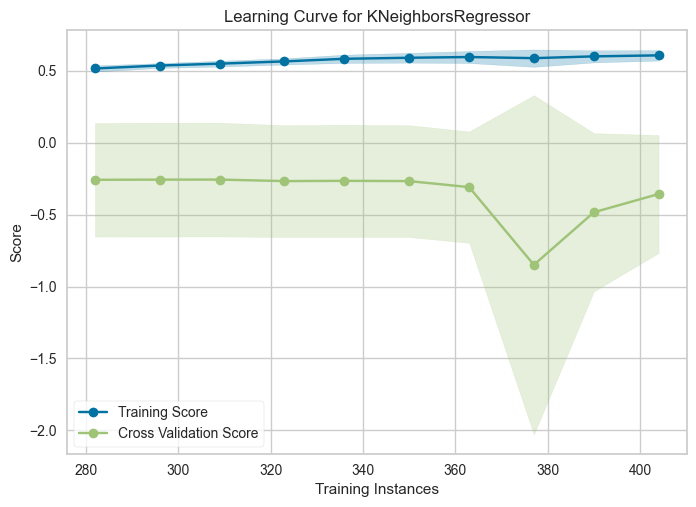

k= 10
Train Accuracy: 0.650012141081337
Test Accuracy: 0.4858233560150279


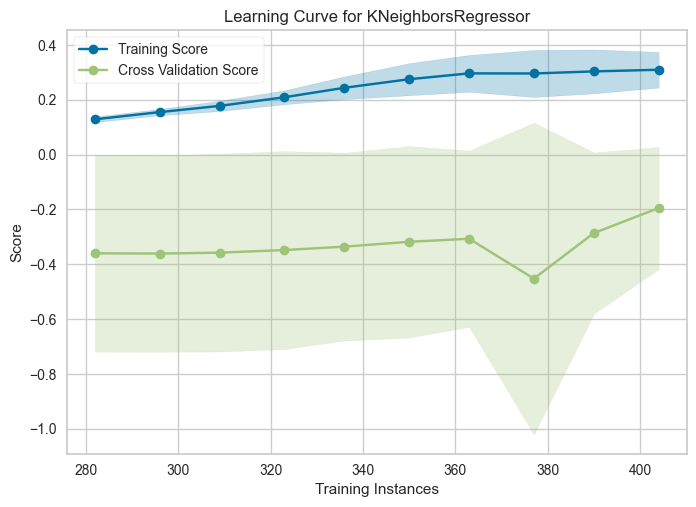

k= 50
Train Accuracy: 0.5424925539121817
Test Accuracy: 0.38905264338779066


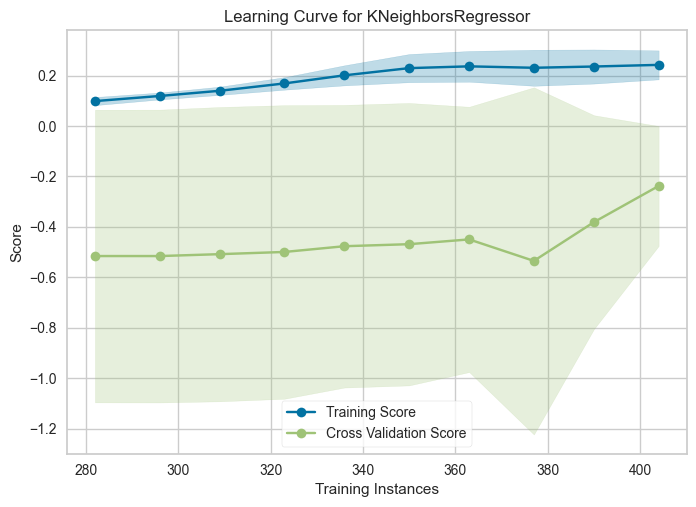

k= 100


In [25]:
from sklearn.neighbors import KNeighborsRegressor

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for k in [3, 5, 10, 50, 100]:

    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    print('Train Accuracy:', knn.score(X_train, y_train))
    print('Test Accuracy:', knn.score(X_test, y_test))
    visualizer = LearningCurve(knn, train_sizes=np.linspace(0.7, 1.0, num=10)).fit(X, y).show()
    print(f'k=', k)



Train Accuracy: 0.8290972700366354
Test Accuracy: 0.6354364289453208


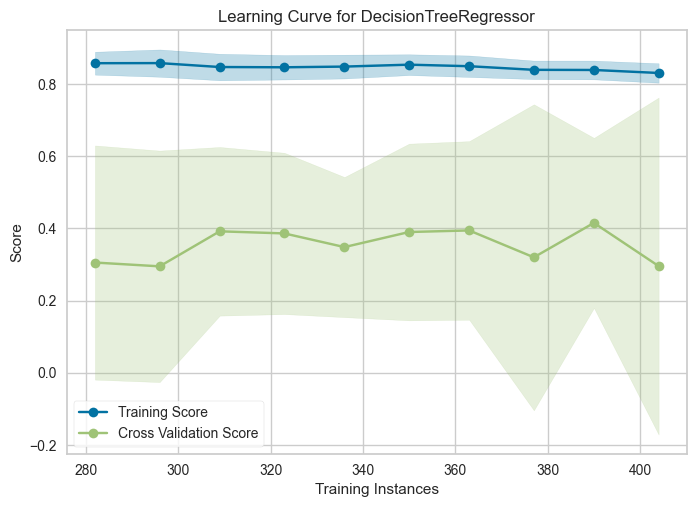

n= 3
Train Accuracy: 0.9292057173968848
Test Accuracy: 0.6727480725849063


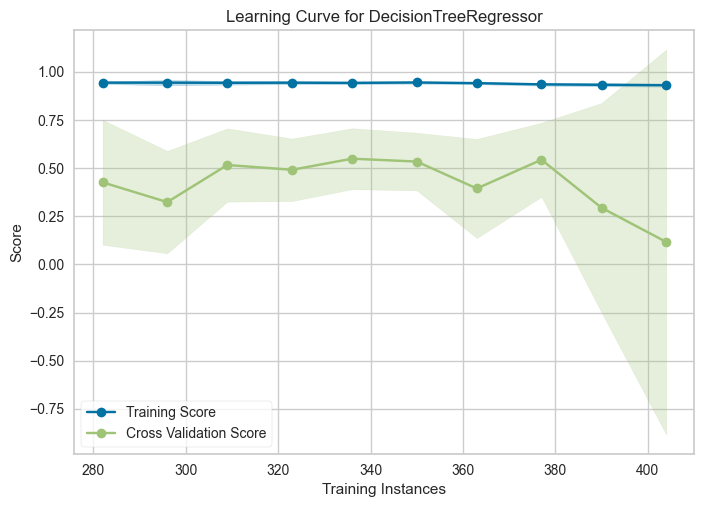

n= 5
Train Accuracy: 0.9941113192452342
Test Accuracy: 0.6362311266281345


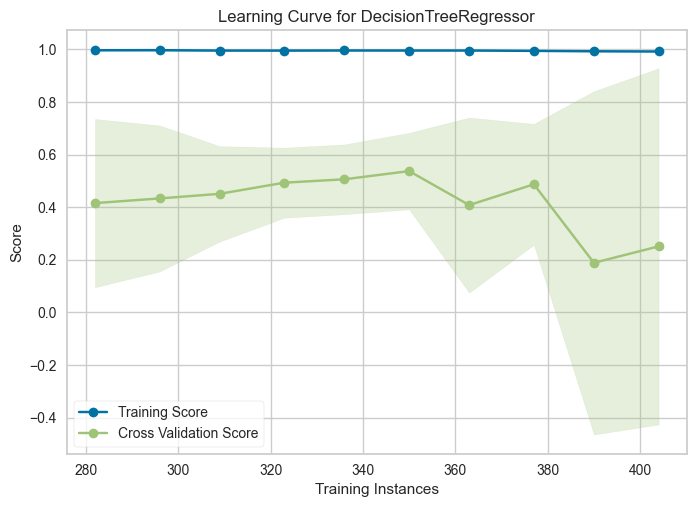

n= 10


In [27]:
from sklearn.tree import DecisionTreeRegressor

for n in [3, 5, 10]:

    tree = DecisionTreeRegressor(max_depth=n)
    tree.fit(X_train, y_train)

    print('Train Accuracy:', tree.score(X_train, y_train))
    print('Test Accuracy:', tree.score(X_test, y_test))
    visualizer = LearningCurve(tree, train_sizes=np.linspace(0.7, 1.0, num=10)).fit(X, y).show()
    print(f'n=', n)



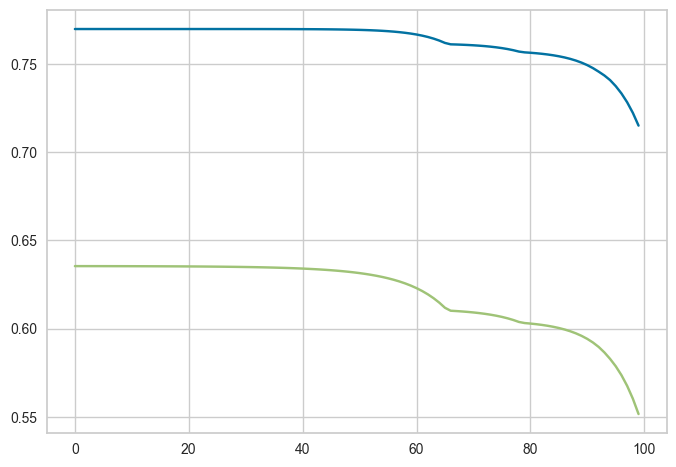

In [8]:
trains = []
tests = []
for i in np.logspace(-4, 0, 100):
    ridge = Lasso(alpha=i).fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label='train')
plt.plot(tests, label='test')
plt.show()




Train Accuracy: 1.0
Test Accuracy: 0.55


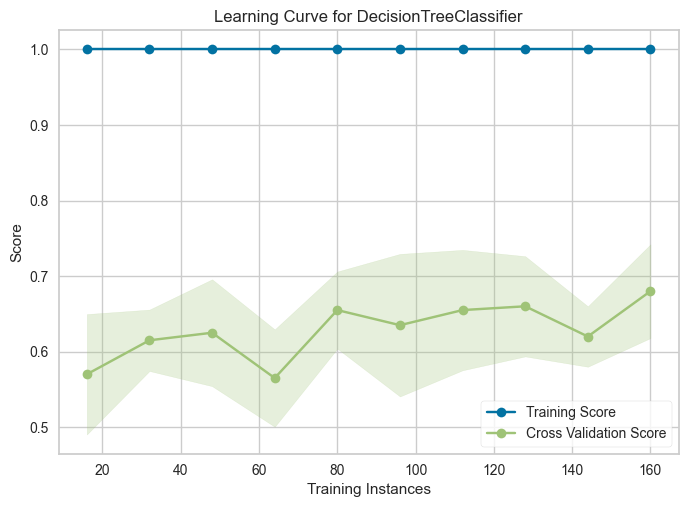

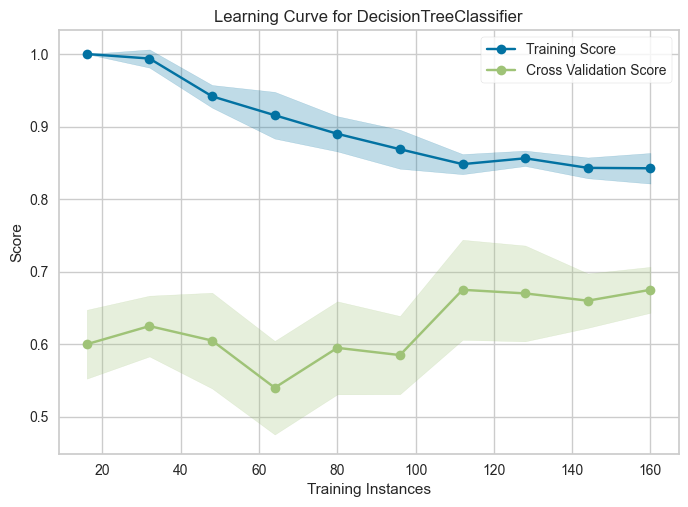

f1 train score 0.76
f1 test score 0.5454545454545454


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv',nrows=200)
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print(f'Train Accuracy:', accuracy_score(y_train, y_train_pred))
print(f'Test Accuracy:', accuracy_score(y_test, y_pred))
visualizer = LearningCurve(model, train_sizes=np.linspace(0.1, 1.0, num=10)).fit(X, y).show()
model1 = DecisionTreeClassifier(max_depth=4)
model1.fit(X_train, y_train)
visualizer = LearningCurve(model1, train_sizes=np.linspace(0.1, 1.0, num=10)).fit(X, y).show()
y_train_pred = model1.predict(X_train)
y_pred = model1.predict(X_test)

print(f'f1 train score', f1_score(y_train, y_train_pred))
print(f'f1 test score', f1_score(y_test, y_pred))

In [10]:
from sklearn.datasets import fetch_openml

df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print(f'Train Accuracy:', accuracy_score(y_train, y_train_pred))
print(f'Test Accuracy:', accuracy_score(y_test, y_pred))


Train Accuracy: 1.0
Test Accuracy: 0.7272727272727273


Train Accuracy: 0.6091530773277223
Test Accuracy: 0.5988779803646563


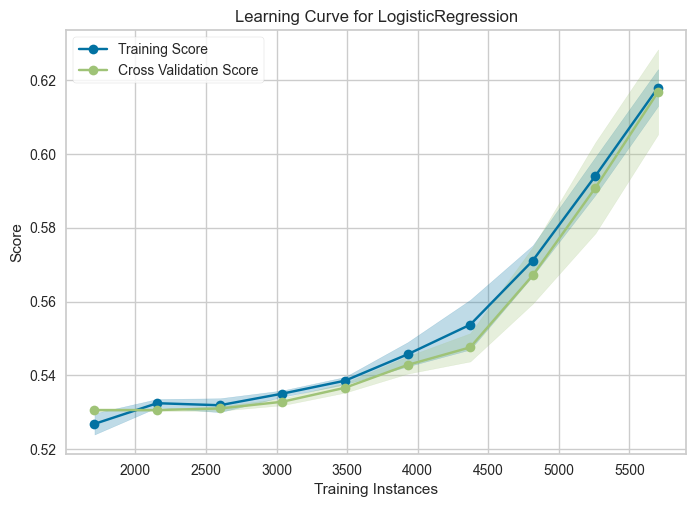

C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Accuracy: 0.9391548307908119
Test Accuracy: 0.9389901823281908


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
 

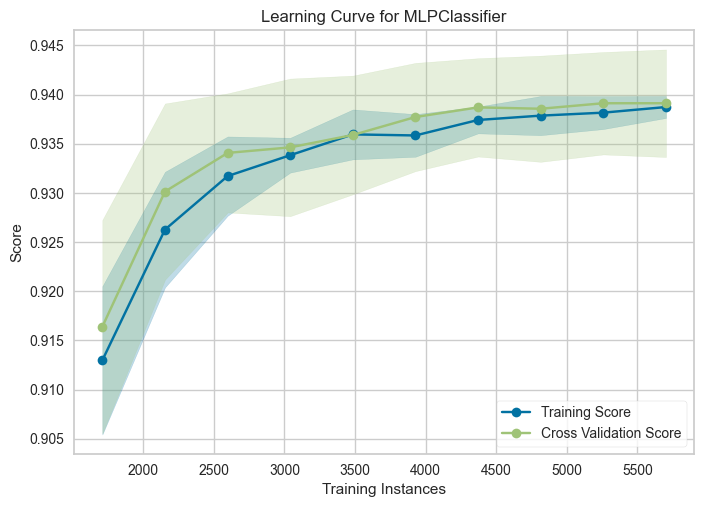

In [11]:
from sklearn.neural_network import MLPClassifier

data = fetch_openml(name='delta_ailerons', parser='auto')
X = pd.get_dummies(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print(f'Train Accuracy:', accuracy_score(y_train, y_train_pred))
print(f'Test Accuracy:', accuracy_score(y_test, y_pred))
visualizer = LearningCurve(model, scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, num=10)).fit(X, y).show()

model = MLPClassifier()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print(f'Train Accuracy:', accuracy_score(y_train, y_train_pred))
print(f'Test Accuracy:', accuracy_score(y_test, y_pred))
visualizer = LearningCurve(model, scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, num=10)).fit(X, y).show()

Train Accuracy: 0.9391548307908119
Test Accuracy: 0.9361851332398317


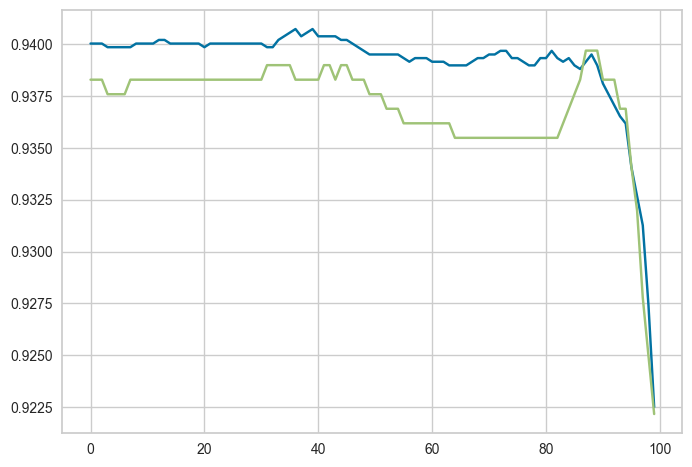

In [12]:
from sklearn.preprocessing import PolynomialFeatures

poly_train = PolynomialFeatures(degree=2).fit_transform(X_train)
poly_test = PolynomialFeatures(degree=2).fit_transform(X_test)

model = RidgeClassifier(alpha=0.001).fit(poly_train, y_train)
y_train_pred = model.predict(poly_train)
y_pred = model.predict(poly_test)
print(f'Train Accuracy:', accuracy_score(y_train, y_train_pred))
print(f'Test Accuracy:', accuracy_score(y_test, y_pred))

trains = []
tests = []
for i in np.logspace(-7, 0, 100):
    ridge = RidgeClassifier(alpha=i).fit(poly_train, y_train)
    trains.append(ridge.score(poly_train, y_train))
    tests.append(ridge.score(poly_test, y_test))

plt.plot(trains, label='train')
plt.plot(tests, label='test')
plt.show()

In [37]:
from sklearn.linear_model import ElasticNet

df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

X = df.drop("medv", axis=1)
y = df["medv"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

alphas = np.logspace(-3, 1, 5)
l1_s = [0.01 , 0.1, 0.5, 0.8, 1]

for a in alphas:
    for l1 in l1_s:
        model = ElasticNet(alpha=a, l1_ratio=l1, max_iter=1000).fit(X_train, y_train)
        print(f'Alpha={a} l1={l1} score={model.score(X_test, y_test)}')


Alpha=0.001 l1=0.01 score=0.635135131061243
Alpha=0.001 l1=0.1 score=0.6351548946873045
Alpha=0.001 l1=0.5 score=0.6352429501077103
Alpha=0.001 l1=0.8 score=0.6353093254674156
Alpha=0.001 l1=1 score=0.6353536557615411
Alpha=0.01 l1=0.01 score=0.6322451290711602
Alpha=0.01 l1=0.1 score=0.6324267266372045
Alpha=0.01 l1=0.5 score=0.6332451179860379
Alpha=0.01 l1=0.8 score=0.6338747779695209
Alpha=0.01 l1=1 score=0.6343067032412265
Alpha=0.1 l1=0.01 score=0.60999558158888
Alpha=0.1 l1=0.1 score=0.6107916759429446
Alpha=0.1 l1=0.5 score=0.6142959990980054
Alpha=0.1 l1=0.8 score=0.6168621758403078
Alpha=0.1 l1=1 score=0.6184027274611757
Alpha=1.0 l1=0.01 score=0.5110860033448463
Alpha=1.0 l1=0.1 score=0.5152213602421768
Alpha=1.0 l1=0.5 score=0.5335518455427088
Alpha=1.0 l1=0.8 score=0.5536524305104069
Alpha=1.0 l1=1 score=0.5637285811120971
Alpha=10.0 l1=0.01 score=0.24865225499497434
Alpha=10.0 l1=0.1 score=0.22473582125762037
Alpha=10.0 l1=0.5 score=0.07419065873823494
Alpha=10.0 l1=0.8 s

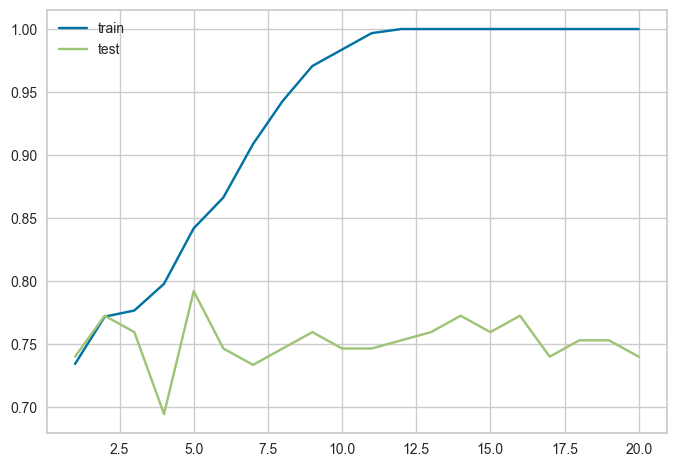

Best depth acc: 5
Best depth f1: 5
Train Accuracy: 0.8420195439739414
Test Accuracy: 0.7922077922077922


In [42]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

depths = range(1, 21)

train_acc = []
test_acc = []

train_f1 = []
test_f1 = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d).fit(X_train, y_train)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_pred))

    train_f1.append(f1_score(y_train, y_train_pred, average='weighted'))
    test_f1.append(f1_score(y_test, y_pred, average='weighted'))

plt.plot(depths, train_acc, label='train')
plt.plot(depths, test_acc, label='test')
plt.legend()
plt.show()

best_depth_acc = depths[np.argmax(test_acc)]
best_depth_f1 = depths[np.argmax(test_f1)]

print('Best depth acc:', best_depth_acc)
print('Best depth f1:', best_depth_f1)

model = DecisionTreeClassifier(max_depth=best_depth_acc).fit(X_train, y_train)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

print(f'Train Accuracy:', accuracy_score(y_train, y_train_pred))
print(f'Test Accuracy:', accuracy_score(y_test, y_pred))
